In [ ]:
#####For one scenario works fine 

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from rasterio.crs import CRS

# classes we care about (case-insensitive)  **ALL LOWERCASE**
INTEREST = {
    "lake plot","premium","regular","residence plots",
    "royal lake plot","sleeping hut","standard","tent",
    "seasonal pitches","VIP" 
}

# bin labels (your semantics)
BINS = [
    (0.10, 0.30, "0.10–0.30 m (tents: flooded)"),
    (0.30, 0.50, "0.30–0.50 m (vehicles: vulnerable)"),
    (0.50, np.inf, ">0.50 m (vehicles: highly vulnerable)")
]

def max_depth_within_buffer(src, x, y, r_m=3.0):
    px = abs(src.transform.a)  # pixel size (m)
    rpx = int(np.ceil(r_m / px))
    r, c = rowcol(src.transform, x, y)
    r0, r1 = max(0, r - rpx), min(src.height - 1, r + rpx)
    c0, c1 = max(0, c - rpx), min(src.width  - 1, c + rpx)

    window = ((r0, r1 + 1), (c0, c1 + 1))
    arr = src.read(1, window=window).astype("float64")

    rr = np.arange(r0, r1 + 1) - r
    cc = np.arange(c0, c1 + 1) - c
    dy = (rr[:, None]) * px
    dx = (cc[None, :]) * px
    dist = np.hypot(dx, dy)
    mask = dist <= r_m

    nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    vals = arr[mask]
    if vals.size == 0 or np.all(np.isnan(vals)):
        return np.nan
    return np.nanmax(vals)

def classify_depth(d):
    if np.isnan(d) or d <= 0.10:
        return "≤0.10 m (not affected)"
    for lo, hi, lab in BINS:
        if (d > lo) and (d <= hi):
            return lab
    return "unclassified"

def overlay_one_scenario(points_path, class_field, raster_path, buffer_m=3.0, assume_crs="EPSG:2056"):
    pts = gpd.read_file(points_path)
    with rasterio.open(raster_path) as src:
        # Use raster CRS if present, else assume EPSG:2056
        src_crs = src.crs or CRS.from_string(assume_crs)

        # Ensure points are in the same CRS
        if pts.crs is None:
            pts = pts.set_crs(src_crs)  # we assume they're actually in this CRS
        else:
            pts = pts.to_crs(src_crs)

        # normalize class names and keep only those of interest
        classes = pts[class_field].astype(str).str.lower().str.strip()
        keep = classes.isin(INTEREST)
        pts = pts.loc[keep].copy()
        classes = classes.loc[keep].reset_index(drop=True)

        # compute max depth within buffer for each point
        depths = np.array([max_depth_within_buffer(src, g.x, g.y, r_m=buffer_m) for g in pts.geometry], dtype=float)

    # classify
    bins = [classify_depth(d) for d in depths]
    df = pd.DataFrame({"class": classes.values, "depth_m": depths, "bin": bins})

    # counts per class & bin (includes "≤0.10 m (not affected)")
    counts = (df.groupby(["class", "bin"])
                .size()
                .reset_index(name="count")
                .sort_values(["class", "bin"]))

    return df, counts

if __name__ == "__main__":
    # inputs
    points = "/rs_scratch/users/ge24z347/Data_forprocess/Exposure_campgrounds/03_Gordevio.shp"  # field 'type'
    raster  = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Gordevio_2m_v2/Gordevio_2m_v2_60_fv1-gpu/Gordevio_2m_v2_75min_60.max"

    # run
    df, counts = overlay_one_scenario(points, "type", raster, buffer_m=3.0)

    # save (to a clear results dir + scenario number from filename)
    outdir = Path("/storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2")
    outdir.mkdir(parents=True, exist_ok=True)
    scenario = Path(raster).stem.split("_")[-1]  # e.g., "60"

    df.to_csv(outdir / f"overlay_points_{scenario}.csv", index=False)
    counts.to_csv(outdir / f"counts_by_class_{scenario}.csv", index=False)
    print("Saved to:", (outdir / f"counts_by_class_{scenario}.csv").resolve())

Saved to: /storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2/counts_by_class_60.csv


In [14]:
#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from rasterio.crs import CRS

# Classes we care about (case-insensitive) — keep ALL lowercase
INTEREST = {
    "lake plot", "premium", "regular", "residence plots",
    "royal lake plot", "sleeping hut", "standard", "tent",
    "seasonal pitches", "VIP"
}

# Bin labels (simple ASCII to avoid encoding issues)
BINS = [
    (0.10, 0.30, "0.10-0.30 m (tents: flooded)"),
    (0.30, 0.50, "0.30-0.50 m (vehicles: vulnerable)"),
    (0.50, np.inf, ">0.50 m (vehicles: highly vulnerable)")
]

def max_depth_within_buffer(src, x, y, r_m=3.0):
    """Return the MAX depth within r_m (meters) of point (x,y) in raster src."""
    px = abs(src.transform.a)  # pixel size in meters
    rpx = int(np.ceil(r_m / px))
    r, c = rowcol(src.transform, x, y)
    r0, r1 = max(0, r - rpx), min(src.height - 1, r + rpx)
    c0, c1 = max(0, c - rpx), min(src.width  - 1, c + rpx)

    window = ((r0, r1 + 1), (c0, c1 + 1))
    arr = src.read(1, window=window).astype("float64")

    rr = np.arange(r0, r1 + 1) - r
    cc = np.arange(c0, c1 + 1) - c
    dy = (rr[:, None]) * px
    dx = (cc[None, :]) * px
    dist = np.hypot(dx, dy)
    mask = dist <= r_m

    nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    vals = arr[mask]
    if vals.size == 0 or np.all(np.isnan(vals)):
        return np.nan
    return float(np.nanmax(vals))

def classify_depth(d):
    """Map a depth value to a bin label."""
    if np.isnan(d) or d <= 0.10:
        return "<=0.10 m (not affected)"
    for lo, hi, lab in BINS:          # bins are (lo, hi], e.g. (0.10, 0.30]
        if (d > lo) and (d <= hi):
            return lab
    return "unclassified"

def overlay_one_scenario(points_path, class_field, raster_path, buffer_m=3.0, assume_crs="EPSG:2056"):
    """Run overlay for one scenario; returns per-point df and grouped counts."""
    pts = gpd.read_file(points_path)
    with rasterio.open(raster_path) as src:
        # Use raster CRS if present; otherwise assume EPSG:2056
        src_crs = src.crs or CRS.from_string(assume_crs)

        # Ensure points match raster CRS
        if pts.crs is None:
            pts = pts.set_crs(src_crs)
        else:
            pts = pts.to_crs(src_crs)

        # Keep only classes of interest (case-insensitive)
        classes = pts[class_field].astype(str).str.lower().str.strip()
        keep = classes.isin(INTEREST)
        pts = pts.loc[keep].copy()
        classes = classes.loc[keep].reset_index(drop=True)

        # Compute max depth within buffer for each point
        depths = np.array([max_depth_within_buffer(src, g.x, g.y, r_m=buffer_m) for g in pts.geometry],
                          dtype=float)

    # Classify depths
    bins = [classify_depth(d) for d in depths]
    df = pd.DataFrame({"class": classes.values, "depth_m": depths, "bin": bins})

    # Counts per class & bin
    counts = (df.groupby(["class", "bin"])
                .size()
                .reset_index(name="count")
                .sort_values(["class", "bin"]))

    return df, counts

def run_many_scenarios(points_path, class_field, build_dir, basename,
                       qs=range(10, 111, 10), buffer_m=3.0,
                       outdir=Path("/storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2")):
    """Loop scenarios, tag with scenario, and save one Excel + CSVs."""
    outdir.mkdir(parents=True, exist_ok=True)
    all_points, all_counts = [], []

    for q in qs:
        raster = Path(build_dir) / f"{basename}_{q}_fv1-gpu" / f"{basename}_75min_{q}.max"
        if not raster.exists():
            print(f"[WARN] Missing raster: {raster}")
            continue

        df, counts = overlay_one_scenario(points_path, class_field, str(raster), buffer_m=buffer_m)
        df["scenario"] = q
        counts["scenario"] = q
        all_points.append(df)
        all_counts.append(counts)

    if not all_points:
        print("No scenarios processed.")
        return

    points_long = pd.concat(all_points, ignore_index=True)
    counts_long = pd.concat(all_counts, ignore_index=True)

    counts_pivot = (counts_long
        .pivot_table(index=["scenario", "class"], columns="bin",
                     values="count", aggfunc="sum", fill_value=0)
        .reset_index()
        .sort_values(["scenario", "class"]))

    # Save CSVs
    counts_long.to_csv(outdir / "counts_long.csv", index=False)
    counts_pivot.to_csv(outdir / "counts_pivot.csv", index=False)

    # Save one Excel with three sheets
    xlsx = outdir / "gordevio_exposure_all_scenarios.xlsx"
    try:
        with pd.ExcelWriter(xlsx, engine="openpyxl") as xw:
            counts_long.to_excel(xw, sheet_name="counts_long", index=False)
            counts_pivot.to_excel(xw, sheet_name="counts_pivot", index=False)
        print("Saved:", xlsx)
    except Exception as e:
        print(f"[INFO] Excel not written ({e}). CSVs are saved in {outdir}")

if __name__ == "__main__":
    # Inputs for Gordevio
    points    = "/rs_scratch/users/ge24z347/Data_forprocess/Exposure_campgrounds/03_Gordevio.shp"  # field 'type'
    build_dir = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Gordevio_2m_v2"
    basename  = "Gordevio_2m_v2"

    # Run all scenarios: 10, 20, ..., 110
    run_many_scenarios(points, "type", build_dir, basename,
                       qs=range(10, 111, 10), buffer_m=2.0)

Saved: /storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2/gordevio_exposure_all_scenarios.xlsx


In [ ]:
###THIS WORKS FINE  with the rentals added.. 
#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
from rasterio.crs import CRS

# ---- classes of interest (keep ALL lowercase) ----
INTEREST = {
    "lake plot", "premium", "regular", "residence plots",
    "royal lake plot", "sleeping hut", "standard", "tent",
    "seasonal pitches", "VIP",
    "rentals", "rental chalet", "villa seeblick"
}

# rentals group uses a single high threshold
FIXED_RENTALS = {"rentals", "rental chalet", "villa seeblick"}
FIXED_THRESHOLD_M = 1.0
FIXED_AFFECTED_LABEL = f">{FIXED_THRESHOLD_M:.1f} m (fixed rentals affected)"

# general bins for non-rental classes (ASCII)
BINS = [
    (0.10, 0.30, "0.10-0.30 m (tents: flooded)"),
    (0.30, 0.50, "0.30-0.50 m (vehicles: vulnerable)"),
    (0.50, np.inf, ">0.50 m (vehicles: highly vulnerable)")
]

def max_depth_within_buffer(src, x, y, r_m=3.0):
    px = abs(src.transform.a)
    rpx = int(np.ceil(r_m / px))
    r, c = rowcol(src.transform, x, y)
    r0, r1 = max(0, r - rpx), min(src.height - 1, r + rpx)
    c0, c1 = max(0, c - rpx), min(src.width  - 1, c + rpx)
    window = ((r0, r1 + 1), (c0, c1 + 1))
    arr = src.read(1, window=window).astype("float64")

    rr = np.arange(r0, r1 + 1) - r
    cc = np.arange(c0, c1 + 1) - c
    dy = (rr[:, None]) * px
    dx = (cc[None, :]) * px
    dist = np.hypot(dx, dy)
    mask = dist <= r_m

    nodata = src.nodata
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    vals = arr[mask]
    if vals.size == 0 or np.all(np.isnan(vals)):
        return np.nan
    return float(np.nanmax(vals))

# return None for "not affected" so it won't be counted/saved
def classify_depth(d, cls_name):
    if np.isnan(d):
        return None

    cls = str(cls_name).lower().strip()
    if cls in FIXED_RENTALS:
        return FIXED_AFFECTED_LABEL if d > FIXED_THRESHOLD_M else None

    if d <= 0.10:
        return None
    for lo, hi, lab in BINS:  # (lo, hi]
        if (d > lo) and (d <= hi):
            return lab
    return None

def overlay_one_scenario(points_path, class_field, raster_path, buffer_m=3.0, assume_crs="EPSG:2056"):
    pts = gpd.read_file(points_path)
    with rasterio.open(raster_path) as src:
        src_crs = src.crs or CRS.from_string(assume_crs)

        if pts.crs is None:
            pts = pts.set_crs(src_crs)
        else:
            pts = pts.to_crs(src_crs)

        classes = pts[class_field].astype(str).str.lower().str.strip()
        keep = classes.isin(INTEREST)
        pts = pts.loc[keep].copy()
        classes = classes.loc[keep].reset_index(drop=True)

        depths = np.array([max_depth_within_buffer(src, g.x, g.y, r_m=buffer_m)
                           for g in pts.geometry], dtype=float)

    bins = [classify_depth(d, c) for d, c in zip(depths, classes.values)]
    df = pd.DataFrame({"class": classes.values, "depth_m": depths, "bin": bins})

    # keep ONLY impacted rows
    df = df[df["bin"].notna()]

    counts = (df.groupby(["class", "bin"])
                .size()
                .reset_index(name="count")
                .sort_values(["class", "bin"]))

    return df, counts

def run_many_scenarios(points_path, class_field, build_dir, basename,
                       qs=range(10, 111, 10), buffer_m=3.0,
                       outdir=Path("/storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2")):
    outdir.mkdir(parents=True, exist_ok=True)
    all_counts = []

    for q in qs:
        raster = Path(build_dir) / f"{basename}_{q}_fv1-gpu" / f"{basename}_75min_{q}.max"
        if not raster.exists():
            print(f"[WARN] Missing raster: {raster}")
            continue

        _, counts = overlay_one_scenario(points_path, class_field, str(raster), buffer_m=buffer_m)
        counts["scenario"] = q
        all_counts.append(counts)

    if not all_counts:
        print("No scenarios processed.")
        return

    counts_long = pd.concat(all_counts, ignore_index=True)

    # pivot of impacted only; include rentals-affected column if present
    bin_order = [
        "0.10-0.30 m (tents: flooded)",
        "0.30-0.50 m (vehicles: vulnerable)",
        ">0.50 m (vehicles: highly vulnerable)",
        FIXED_AFFECTED_LABEL,  # >1.0 m for rentals group
    ]
    counts_pivot = (counts_long
        .pivot_table(index=["scenario", "class"], columns="bin",
                     values="count", aggfunc="sum", fill_value=0)
        .reindex(columns=[b for b in bin_order if b in counts_long["bin"].unique()])
        .reset_index()
        .sort_values(["scenario", "class"]))

    # Save CSVs + Excel
    counts_long.to_csv(outdir / "counts_long.csv", index=False)
    counts_pivot.to_csv(outdir / "counts_pivot.csv", index=False)

    xlsx = outdir / "gordevio_exposure_all_scenarios.xlsx"
    try:
        with pd.ExcelWriter(xlsx, engine="openpyxl") as xw:
            counts_long.to_excel(xw, sheet_name="counts_long", index=False)
            counts_pivot.to_excel(xw, sheet_name="counts_pivot", index=False)
        print("Saved:", xlsx)
    except Exception as e:
        print(f"[INFO] Excel not written ({e}). CSVs are saved in {outdir}")

if __name__ == "__main__":
    points    = "/rs_scratch/users/ge24z347/Data_forprocess/Exposure_campgrounds/03_Gordevio.shp"  # field 'type'
    build_dir = "/storage/homefs/ge24z347/LISFLOOD_FP_8_1/build/Gordevio_2m_v2"
    basename  = "Gordevio_2m_v2"

    run_many_scenarios(points, "type", build_dir, basename,
                       qs=range(10, 111, 10), buffer_m=2.0)

Saved: /storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2/gordevio_exposure_all_scenarios.xlsx


Saved plot: /storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2/Impact_Gordevio_scenarios.png


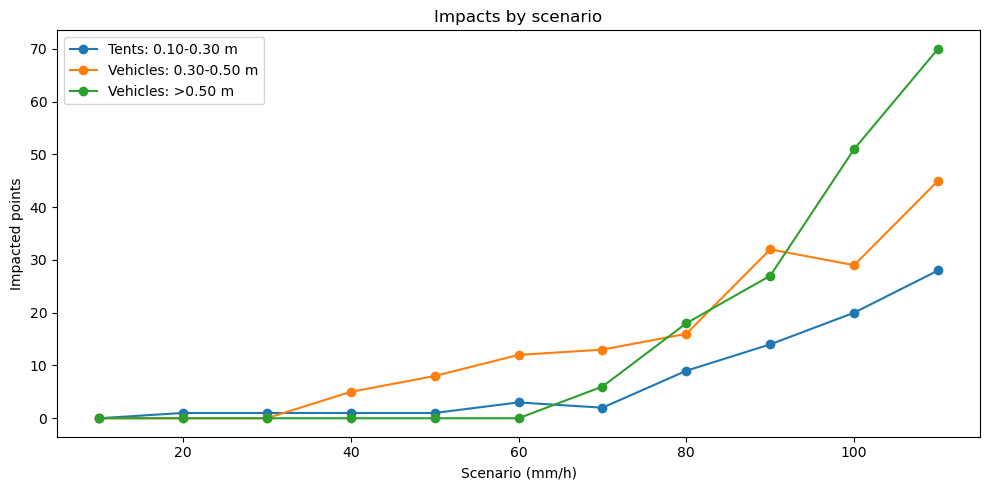

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- paths
outdir = Path("/storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_v2")
outdir.mkdir(parents=True, exist_ok=True)
csv = outdir / "counts_pivot.csv"

# --- column labels (must match your CSV headers)
COL_TENT = "0.10-0.30 m (tents: flooded)"
COL_VULN = "0.30-0.50 m (vehicles: vulnerable)"
COL_SEV  = ">0.50 m (vehicles: highly vulnerable)"

# rentals threshold label used by your main script
FIXED_THRESHOLD_M = 1.0
RENTALS_LABEL = f">{FIXED_THRESHOLD_M:.1f} m (fixed rentals affected)"

# --- class groups
VEHICLE_CLASSES = {
    "lake plot", "premium", "regular", "residence plots",
    "royal lake plot", "sleeping hut", "standard", "seasonal pitches", "vip",
}
RENTAL_GROUP = {"rentals", "rental chalet", "villa seeblick"}

# --- load data
df = pd.read_csv(csv)
df["class"] = df["class"].str.lower().str.strip()
df = df.sort_values(["scenario", "class"])

# be resilient to missing columns
for col in (COL_TENT, COL_VULN, COL_SEV):
    if col not in df.columns:
        df[col] = 0

# detect rentals column if present
rentals_col = RENTALS_LABEL if RENTALS_LABEL in df.columns else None
if rentals_col is None:
    for c in df.columns:
        if "fixed rentals affected" in c:
            rentals_col = c
            break

# --- build series
s_tents = (df[df["class"] == "tent"]
           .groupby("scenario")[COL_TENT]
           .sum())

mask_vehicle = df["class"].isin(VEHICLE_CLASSES)
s_vuln = df[mask_vehicle].groupby("scenario")[COL_VULN].sum()
s_sev  = df[mask_vehicle].groupby("scenario")[COL_SEV].sum()

if rentals_col:
    mask_rent = df["class"].isin(RENTAL_GROUP)
    s_rent = df[mask_rent].groupby("scenario")[rentals_col].sum()
else:
    s_rent = pd.Series(dtype=float)

# align indices
scenarios = sorted(set(s_tents.index) | set(s_vuln.index) | set(s_sev.index) | set(s_rent.index))
s_tents = s_tents.reindex(scenarios, fill_value=0)
s_vuln  = s_vuln.reindex(scenarios,  fill_value=0)
s_sev   = s_sev.reindex(scenarios,   fill_value=0)
s_rent  = s_rent.reindex(scenarios,  fill_value=0) if not s_rent.empty else pd.Series([0]*len(scenarios), index=scenarios)

# --- plot (no alert line)
plt.figure(figsize=(10,5))
plt.plot(scenarios, s_tents.values, marker="o", label="Tents: 0.10-0.30 m")
plt.plot(scenarios, s_vuln.values,  marker="o", label="Vehicles: 0.30-0.50 m")
plt.plot(scenarios, s_sev.values,   marker="o", label="Vehicles: >0.50 m")
if rentals_col:
    plt.plot(scenarios, s_rent.values, marker="o", label="Rentals group: >1.0 m")

plt.xlabel("Scenario (mm/h)")
plt.ylabel("Impacted points")
plt.title("Impacts by scenario")
plt.legend()
plt.tight_layout()

outfile = outdir / "Impact_Gordevio_scenarios.png"
plt.savefig(outfile, dpi=150)
print("Saved plot:", outfile.resolve())

Saved: /storage/homefs/ge24z347/exposure_results_campgrounds/Gordevio_2m_all_versions/Impact_Gordevio_ALL_versions.png


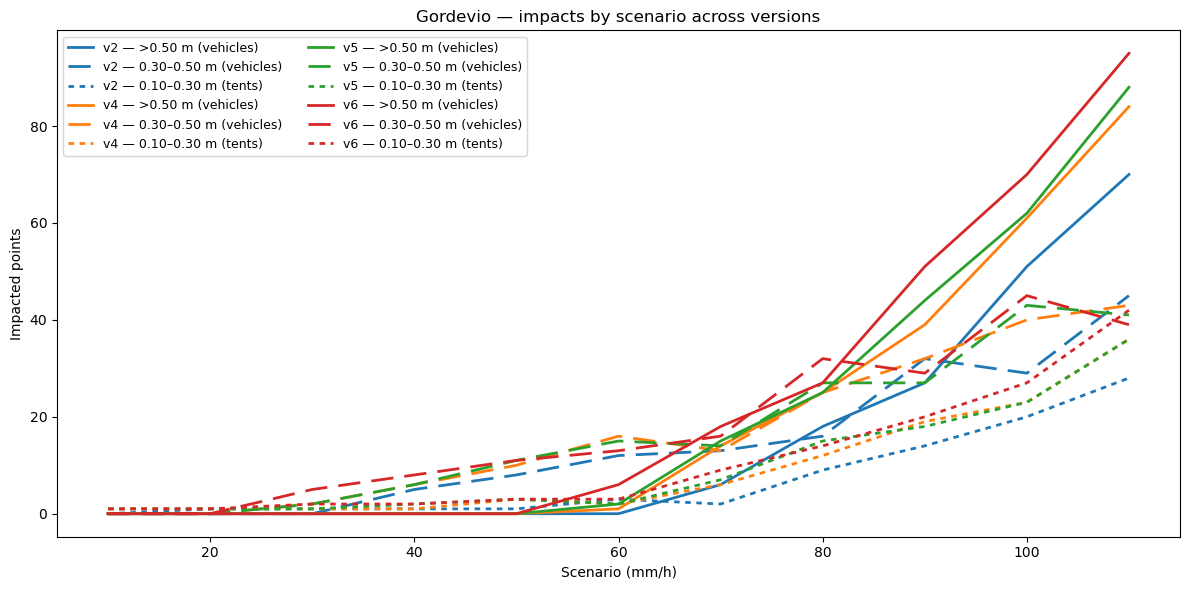

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- edit just this block if paths change ----------------
base = Path("/storage/homefs/ge24z347/exposure_results_campgrounds")
cases = [
    ("v2", base / "Gordevio_2m_v2"),
    ("v4", base / "Gordevio_2m_v4"),
    ("v5", base / "Gordevio_2m_v5"),
    ("v6", base / "Gordevio_2m_v6"),
]
outdir = base / "Gordevio_2m_all_versions"
outdir.mkdir(parents=True, exist_ok=True)
outfile = outdir / "Impact_Gordevio_ALL_versions.png"
# ---------------------------------------------------------------------

# column labels (must match your CSV headers)
COL_TENT = "0.10-0.30 m (tents: flooded)"
COL_VULN = "0.30-0.50 m (vehicles: vulnerable)"
COL_SEV  = ">0.50 m (vehicles: highly vulnerable)"
RENTALS_LABEL = ">1.0 m (fixed rentals affected)"  # adjust if you changed the label in the overlay script

VEHICLE_CLASSES = {
    "lake plot", "premium", "regular", "residence plots",
    "royal lake plot", "sleeping hut", "standard", "seasonal pitches", "vip",
}
RENTAL_GROUP = {"rentals", "rental chalet", "villa seeblick"}

def load_series(pivot_csv: Path):
    df = pd.read_csv(pivot_csv)
    if df.empty:
        return [], pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float)

    df["class"] = df["class"].str.lower().str.strip()
    df = df.sort_values(["scenario", "class"])

    for col in (COL_TENT, COL_VULN, COL_SEV):
        if col not in df.columns:
            df[col] = 0

    rentals_col = RENTALS_LABEL if RENTALS_LABEL in df.columns else None
    if rentals_col is None:
        for c in df.columns:
            if "fixed rentals affected" in c:
                rentals_col = c
                break

    s_tents = (df[df["class"] == "tent"].groupby("scenario")[COL_TENT].sum())
    mask_vehicle = df["class"].isin(VEHICLE_CLASSES)
    s_vuln = df[mask_vehicle].groupby("scenario")[COL_VULN].sum()
    s_sev  = df[mask_vehicle].groupby("scenario")[COL_SEV].sum()

    if rentals_col:
        mask_rent = df["class"].isin(RENTAL_GROUP)
        s_rent = df[mask_rent].groupby("scenario")[rentals_col].sum()
    else:
        s_rent = pd.Series(dtype=float)

    scenarios = sorted(set(s_tents.index) | set(s_vuln.index) | set(s_sev.index) | set(s_rent.index))
    s_tents = s_tents.reindex(scenarios, fill_value=0)
    s_vuln  = s_vuln.reindex(scenarios,  fill_value=0)
    s_sev   = s_sev.reindex(scenarios,   fill_value=0)
    s_rent  = s_rent.reindex(scenarios,  fill_value=0) if not s_rent.empty else pd.Series([0]*len(scenarios), index=scenarios)

    return scenarios, s_tents, s_vuln, s_sev, s_rent

# gather series
series_by_case = []
for label, cdir in cases:
    csv = cdir / "counts_pivot.csv"
    if not csv.exists():
        print(f"[WARN] Missing: {csv}")
        continue
    scenarios, s_tents, s_vuln, s_sev, s_rent = load_series(csv)
    if len(scenarios) == 0:
        print(f"[INFO] No data to plot for {label}")
        continue
    series_by_case.append({
        "label": label, "scenarios": scenarios,
        "tents": s_tents, "vuln": s_vuln, "sev": s_sev, "rent": s_rent
    })

if not series_by_case:
    raise SystemExit("No cases had data to plot.")

# common x-axis
all_scenarios = sorted(set().union(*[set(s["scenarios"]) for s in series_by_case]))

plt.figure(figsize=(12,6))

# line styles: what you requested
# - sev (>0.50): solid
# - vuln (0.30–0.50): long dashes
# - tents (0.10–0.30): short dashes
# - rent: dash-dot
dash_vuln  = (0, (8, 4))   # long dashes
dash_tents = (0, (2, 2))   # short dashes

colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0","C1","C2","C3","C4","C5"])

for i, item in enumerate(series_by_case):
    color = colors[i % len(colors)]
    t = item["tents"].reindex(all_scenarios, fill_value=0)
    v = item["vuln"].reindex(all_scenarios,  fill_value=0)
    s = item["sev"].reindex(all_scenarios,   fill_value=0)
    r = item["rent"].reindex(all_scenarios,  fill_value=0)

    # vehicles >0.50 (solid)
    plt.plot(all_scenarios, s.values, linestyle='-',  linewidth=2,
             color=color, label=f"{item['label']} — >0.50 m (vehicles)")
    # vehicles 0.30–0.50 (long dashes)
    plt.plot(all_scenarios, v.values, linestyle=dash_vuln, linewidth=2,
             color=color, label=f"{item['label']} — 0.30–0.50 m (vehicles)")
    # tents 0.10–0.30 (short dashes)
    plt.plot(all_scenarios, t.values, linestyle=dash_tents, linewidth=2,
             color=color, label=f"{item['label']} — 0.10–0.30 m (tents)")
    # rentals >1.0 m (dash-dot) only if present anywhere
    if (r.values > 0).any():
        plt.plot(all_scenarios, r.values, linestyle='-.', linewidth=2,
                 color=color, label=f"{item['label']} — >1.0 m (rentals)")

plt.xlabel("Scenario (mm/h)")
plt.ylabel("Impacted points")
plt.title("Gordevio — impacts by scenario across versions")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(outfile, dpi=150)
print("Saved:", outfile.resolve())